In [1]:
# Libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [2]:
# Use moon dataset from sklean for real world usecase
X_np , Y_np = make_moons(n_samples=10000 , noise = 0.1 , random_state=42)

df = pd.DataFrame(X_np , columns=["x" , "y"])
df["label"] = Y_np

# saving the data to data.csv for gradio 
# app and visualizer to have the new points
df.to_csv("data.csv" , index = False) 

print(df.head())

          x         y  label
0  0.455493 -0.125503      1
1 -0.704217  0.041308      0
2  0.413799  0.791322      0
3 -0.864049  0.138754      0
4 -0.936268  0.359267      0


In [3]:
# Seperate X and Y

# X contains 2 points -> x , y
X = torch.tensor(
    df[["x" , "y"]].values,
    dtype=torch.float32 
)

# Y contains 0/1 label 
Y = torch.tensor(
    df["label"].values,
    dtype = torch.float32 
).reshape(-1, 1)

print(f"X shape : {X.shape}")
print(f"Y shape : {Y.shape}")

X shape : torch.Size([10000, 2])
Y shape : torch.Size([10000, 1])


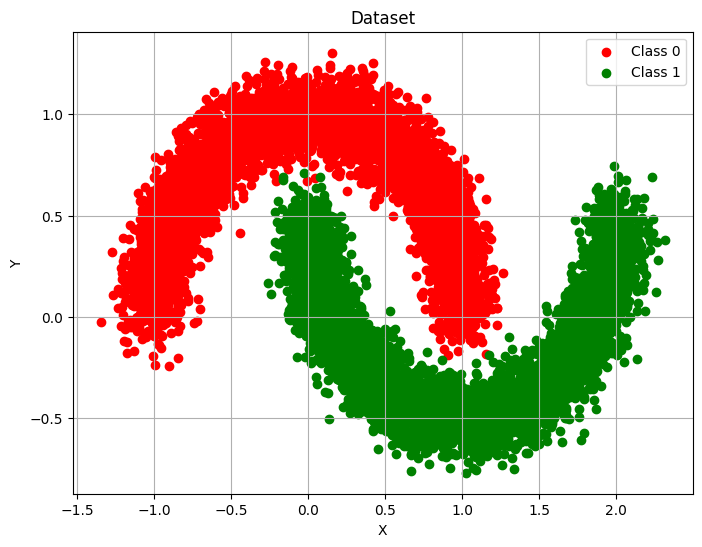

In [4]:
# Select class 0 points.
class_0 = X[Y[:, 0] == 0]

# Select class 1 points.
class_1 = X[Y[:, 0] == 1]


plt.figure(figsize=(8, 6))

plt.scatter(
    class_0[:, 0],
    class_0[:, 1],
    color="red",
    label="Class 0"
)

plt.scatter(
    class_1[:, 0],
    class_1[:, 1],
    color="green",
    label="Class 1"
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Dataset")

plt.legend()
plt.grid(True)

plt.show()


In [5]:
# Shuffle the data
torch.manual_seed(42)
num_samples = X.shape[0]
indices = torch.randperm(num_samples)

# 80% training data
train_size = int(0.8 * num_samples)
training_indices = indices[:train_size]

# 20% testing data
testing_indices = indices[train_size:]

# create training and testing data 
x_train = X[training_indices]
y_train = Y[training_indices]

x_test = X[testing_indices]
y_test = Y[testing_indices]

print(f"X training shape : {x_train.shape} | Y training shape : {y_train.shape}")
print(f"X testing shape : {x_test.shape} | Y testing shape : {y_test.shape}")

X training shape : torch.Size([8000, 2]) | Y training shape : torch.Size([8000, 1])
X testing shape : torch.Size([2000, 2]) | Y testing shape : torch.Size([2000, 1])


In [6]:
# Normalize the data

# calculate mean & std deviation from training data 
mean = x_train.mean(dim=0)
std = x_train.std(dim=0)

# normalize training data
x_train = (x_train - mean) / std 

# normalize testing data
x_test = (x_test - mean) / std

print(f"Train samples: {x_train.shape[0]} | Test samples: {x_test.shape[0]}")
print(f"Mean: {mean} | Std: {std}")

Train samples: 8000 | Test samples: 2000
Mean: tensor([0.4970, 0.2493]) | Std: tensor([0.8775, 0.5034])


In [7]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2 , 16)
        self.layer2 = nn.Linear(16 , 16)
        self.output = nn.Linear(16 , 1)

    def forward(self , x):
        x = torch.tanh(self.layer1(x))
        x = torch.tanh(self.layer2(x))
        x = self.output(x)

        return x 

model = Net()
print(model)

Net(
  (layer1): Linear(in_features=2, out_features=16, bias=True)
  (layer2): Linear(in_features=16, out_features=16, bias=True)
  (output): Linear(in_features=16, out_features=1, bias=True)
)


In [8]:
# loss function
# BCEWithLogitsLoss() -> sigmoid + binary cross entropy
criterion = nn.BCEWithLogitsLoss()

# optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr = 0.01
)

In [9]:
from torch.utils.data import DataLoader , TensorDataset
# Train the network with full batch training
# epochs = 500
loss_history = []

# for epoch in range(epochs):
#     # 1. forward pass 
#     preds = model(x_train)

#     # 2. Compute loss 
#     loss = criterion(
#         preds,
#         y_train
#     )

#     # 3. clear gradients 
#     optimizer.zero_grad()

#     # 4. Back prop 
#     loss.backward()

#     # 5. Compute gradient descent 
#     optimizer.step()

# Mini-batch training 
epochs = 50
batch_size = 32
train_dataset = TensorDataset(x_train , y_train)
train_loader = DataLoader(train_dataset , batch_size)

print("----------Training started-----------")

for epoch in range(epochs):
    model.train()
    total_loss = 0.0

    for xb , yb in train_loader:    
        # 1. Forward pass 
        preds = model(xb)

        # 2. Compute loss 
        loss = criterion(preds , yb)

        # 3. Clear gradients 
        optimizer.zero_grad()

        # 4. Back prop 
        loss.backward()

        # 5. Gradient Descent / Optimization
        optimizer.step()

        total_loss += loss.item() * len(xb)

    epoch_loss = total_loss / len(train_dataset)
    loss_history.append(epoch_loss)

    # Print progress.
    if epoch % 5 == 0:
        print(
            f"Epoch: {epoch} | "
            f"Loss: {loss.item():.4f}"
        )

----------Training started-----------
Epoch: 0 | Loss: 0.0062
Epoch: 5 | Loss: 0.0000
Epoch: 10 | Loss: 0.0000
Epoch: 15 | Loss: 0.0000
Epoch: 20 | Loss: 0.0000
Epoch: 25 | Loss: 0.0000
Epoch: 30 | Loss: 0.0000
Epoch: 35 | Loss: 0.0000
Epoch: 40 | Loss: 0.0000
Epoch: 45 | Loss: 0.0000


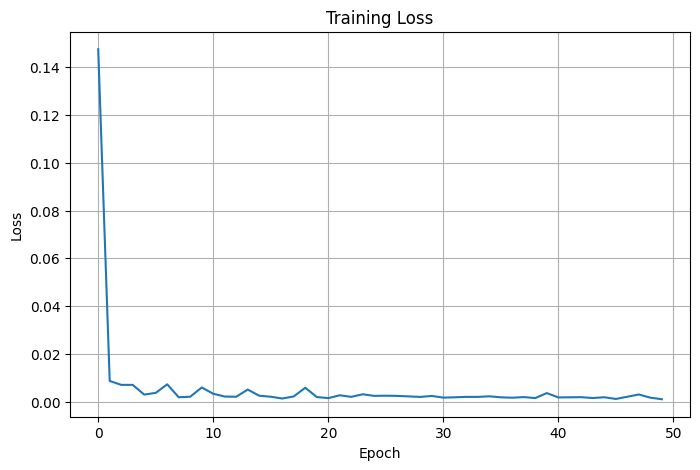

In [11]:
# Plot the training loss

plt.figure(figsize=(8, 5))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training Loss")

plt.grid(True)

plt.show()


In [14]:
# # Evaluate test data

# model.eval()

# # Disable gradient calculation because we aren't training.
# with torch.no_grad():
#     test_logits = model(x_test)

# # Convert logits into probabilities.
# #
# # sigmoid converts:
# #
# #     -large number → close to 0
# #     +large number → close to 1
# #
# test_probabilities = torch.sigmoid(test_logits)

# # convert probs into classes
# test_predictions = (
#     test_probabilities >= 0.5
# ).float()

# # Calculate accuracy.
# accuracy = (
#     test_predictions == y_test
# ).float().mean()

# print(
#     f"Test accuracy: {accuracy.item() * 100:.2f}%"
# )

model.eval()
with torch.no_grad():
    train_preds = (torch.sigmoid(model(x_train)) >= 0.5).float()
    train_acc = (train_preds == y_train).float().mean().item() * 100
    test_preds = (torch.sigmoid(model(x_test)) >= 0.5).float()
    test_acc = (test_preds == y_test).float().mean().item() * 100
print(f"\nFinal Results:")
print(f"Train Accuracy: {train_acc:.2f}%")
print(f"Test Accuracy : {test_acc:.2f}%")


Final Results:
Train Accuracy: 99.95%
Test Accuracy : 99.90%


In [15]:
# 1. Save Model Checkpoint (Weights + Normalization Stats)
checkpoint = {
    "model_stat_dict" : model.state_dict(),
    "mean" : mean,
    "std" : std,
    "train_accuracy" : train_acc,
    "test_accuracy" : test_acc,
    "input_dim" : 2,
    "hidden_dim" : 16,
    "output_dim" : 1
}

torch.save(checkpoint , "model.pth")
print("Saved checkpoint to modeo.pth")

Saved checkpoint to modeo.pth


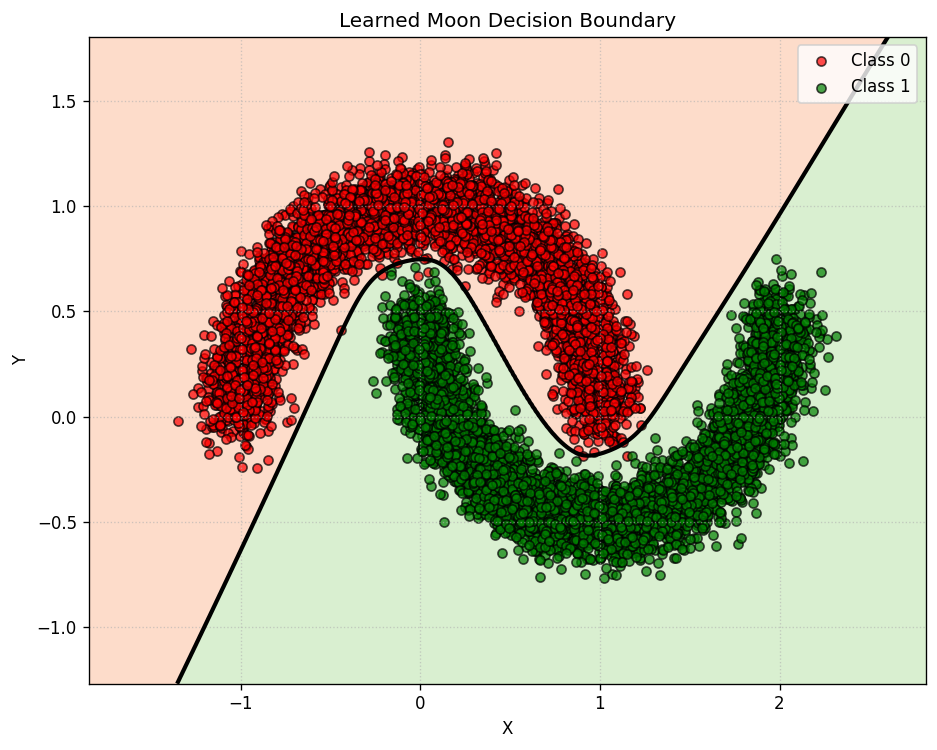

In [17]:
# Generate 2D Coordinate Grid for Decision Boundary
class_0 = X[Y[:, 0] == 0]
class_1 = X[Y[:, 0] == 1]
x_min, x_max = X[:, 0].min().item() - 0.5, X[:, 0].max().item() + 0.5
y_min, y_max = X[:, 1].min().item() - 0.5, X[:, 1].max().item() + 0.5
grid_size = 300
grid_x = torch.linspace(x_min, x_max, grid_size)
grid_y = torch.linspace(y_min, y_max, grid_size)
xx, yy = torch.meshgrid(grid_x, grid_y, indexing="xy")
grid_points = torch.stack([xx.flatten(), yy.flatten()], dim=1)
grid_points_norm = (grid_points - mean) / std

# Model Inference on Grid
with torch.no_grad():
    grid_logits = model(grid_points_norm)
    grid_probs = torch.sigmoid(grid_logits)
Z = grid_probs.reshape(grid_size, grid_size).numpy()

# Plot Decision Boundary
plt.figure(figsize=(9, 7), dpi=120)
plt.contourf(
    xx.numpy(), yy.numpy(), Z,
    levels=[0, 0.5, 1],
    cmap="RdYlGn",
    alpha=0.3
)
plt.scatter(
    class_0[:, 0], class_0[:, 1],
    color="red", label="Class 0",
    edgecolors="black", s=30, alpha=0.7
)
plt.scatter(
    class_1[:, 0], class_1[:, 1],
    color="green", label="Class 1",
    edgecolors="black", s=30, alpha=0.7
)
plt.contour(
    xx.numpy(), yy.numpy(), Z,
    levels=[0.5],
    colors="black",
    linewidths=2.5
)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Learned Moon Decision Boundary")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.savefig("assets/decision_boundary.png", bbox_inches="tight")
plt.show()

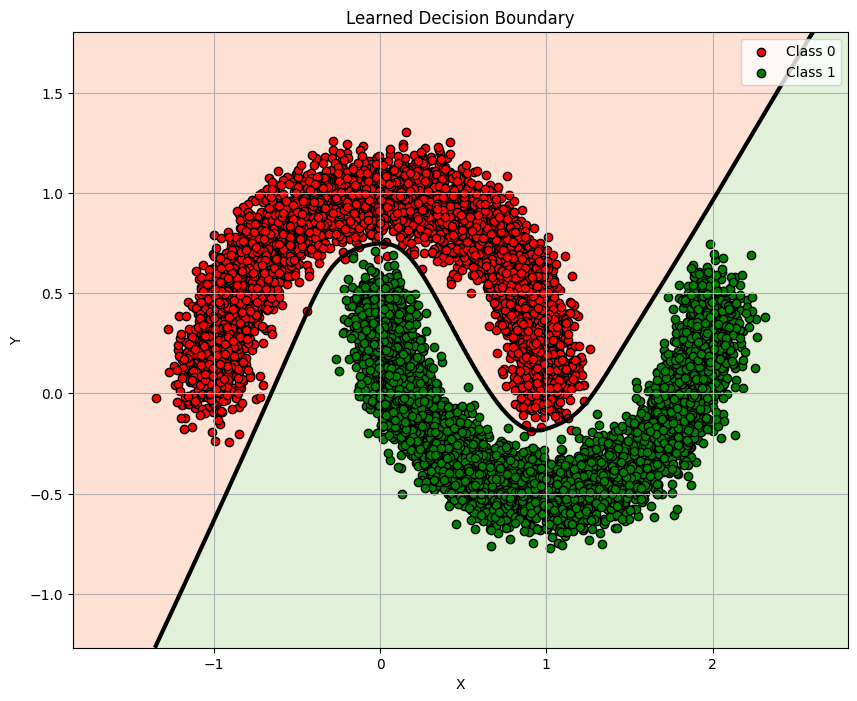

In [18]:
plt.figure(figsize=(10, 8))


# ----------------------------------------------------------
# Background color represents the network's prediction.
# ----------------------------------------------------------

plt.contourf(
    xx,
    yy,
    Z,
    levels=[0, 0.5, 1],
    cmap="RdYlGn",
    alpha=0.25
)


# ----------------------------------------------------------
# Original data points.
# ----------------------------------------------------------

plt.scatter(
    class_0[:, 0],
    class_0[:, 1],
    color="red",
    label="Class 0",
    edgecolors="black"
)

plt.scatter(
    class_1[:, 0],
    class_1[:, 1],
    color="green",
    label="Class 1",
    edgecolors="black"
)


# ----------------------------------------------------------
# Exact 0.5 boundary.
# ----------------------------------------------------------

plt.contour(
    xx,
    yy,
    Z,
    levels=[0.5],
    colors="black",
    linewidths=3
)


plt.xlabel("X")
plt.ylabel("Y")

plt.title(
    "Learned Decision Boundary"
)

plt.legend()
plt.grid(True)

plt.show()
